# Matching - PySpark version

In [1]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 3, Finished, Available, Finished, False)

In [20]:
%run ./matching_process

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 28, Finished, Available, Finished, True)

In [19]:
%run ./prepare_matching_data

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 27, Finished, Available, Finished, True)

In [15]:
%run ./matching_validation

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 23, Finished, Available, Finished, True)

In [16]:
%run ./prepare_matching_data

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 24, Finished, Available, Finished, True)

In [17]:
%run ./consumption_cohort

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 25, Finished, Available, Finished, True)

## Load Data

In [7]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
month_result_all= month_result[month_result["price"]== "all"] 
print(month_result.shape)
print(month_result_all.shape)
month_result_spark= spark.createDataFrame(month_result_all)

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 12, Finished, Available, Finished, False)

(4538578, 17)
(1854385, 17)


## Matching


StatementMeta(, e406ffbd-ae73-4018-be38-b55f99de611c, 13, Finished, Available, Finished, False)

Preparing risk set...
Preparing base data...
Building risk set...
risk_rows count = 5684081
Running time series matching...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building fixed-lag time series profiles ...
profiles count = 473434
Standardizing by controls ...
profiles_z count = 473434
Matching top-k ...
=== VALID DIMENSION DISTRIBUTION =

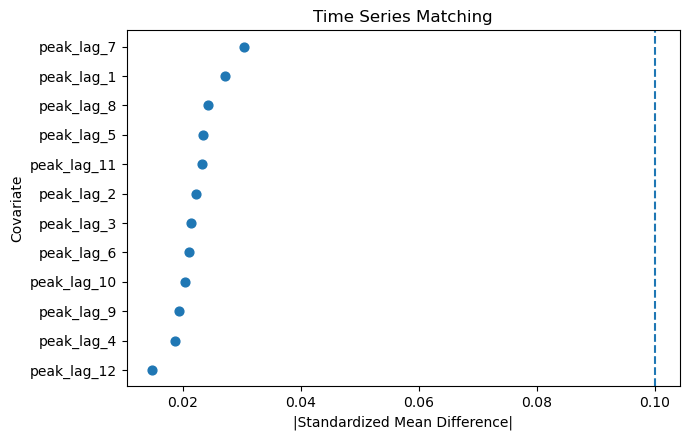

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 117167
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 117607
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [12, 0) ===

--- OVERALL ---
+--------------------+-------------------+------------------+---------------------+
|covariate           |treated_mean       |control_mean      |SMD                  |
+--------------------+-------------------+------------------+---------------------+
|peak_mean           |6.306996308293977  |6.22958561337306  |0.02461389909637383  |
|peak_sd             |1.4089585090897387 |1.253265010116124 |0.16460411621166074  |
|peak_volatility     |0.9090678685199106 |0.7238990417186172|0.36008087602692374  |
|mean_consumption    |1.3375387912036305 |1.49535441

In [8]:
# ============================================================
# Step 1: build risk_rows（只做一次）
# ============================================================

print("Preparing risk set...")

risk_rows = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: time series matching
# ============================================================

print("Running time series matching...")

res_ts = run_time_series_matching_pipeline(
    risk_rows=risk_rows,   # ✅ 改這裡
    output_folder="Files/output/matching/time_series",
    lookback_months=12,
    verbose=True,
    save_output=False,
    control_type="never_treated"
)



# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_ts,
    folder="Files/output/matching/time_series",
    config={
        "type": "time_series",
        "lookback_months": 12
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_ts["balance"],
    output_path=None,
    title="Time Series Matching"
)


# ============================================================
# Step 5: validation
# ============================================================
check_balance_full_safe(
    res=res_ts,
    sdf=month_result_spark,

    # Matching variables → NON-overlapping window
    match_start_month=24,
    match_end_month=12,

    # Non-matching variables → long window
    extra_start_month= 12,
    extra_end_month=0,

    # Calendar (seasonality)
    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 29, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 11355189
Running calendar matching...
Running calendar-aligned matching...
risk_rows count = 11355189
+----------+-------+-------+
|Ti        |group  |count  |
+----------+-------+-------+
|2025-03-01|control|1129558|
|2025-03-01|treated|14952  |
|2025-04-01|control|1130134|
|2025-04-01|treated|8010   |
|2025-05-01|control|1130709|
|2025-05-01|treated|3358   |
|2025-06-01|control|1131266|
|2025-06-01|treated|3000   |
|2025-07-01|control|1131805|
|2025-07-01|treated|1536   |
|2025-08-01|control|1131962|
|2025-08-01|treated|960    |
|2025-09-01|control|1132102|
|2025-09-01|treated|1176   |
|2025-10-01|control|1132228|
|2025-10-01|treated|1200   |
|2025-11-01|control|1132347|
|2025-11-01|treated|3529   |
|2025-12-01|control|1132453|
|2025-12-01|treated|2904   |
+----------+-------+-------+

Building calendar-aligned profiles ...
profiles count = 473892
Standardizing by controls

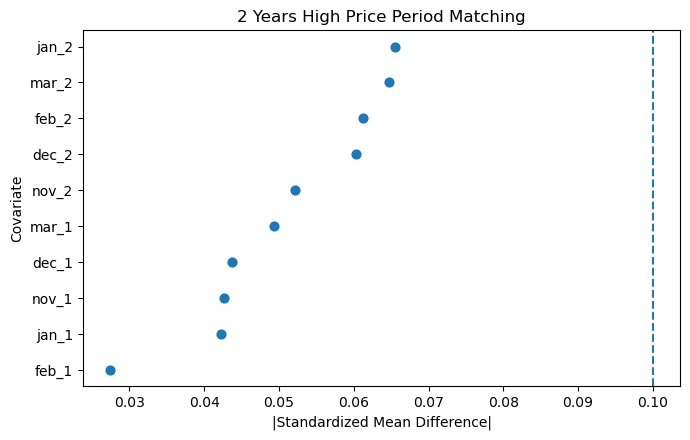

Rebuilding validation data...
  Matching vars window:     [t-24, t-0)
  Non-matching vars window: [t-24, t-0)
Validation rows (matching vars) count = 214391
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 214391
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [24, 0) ===

--- OVERALL ---
+--------------------+-------------------+-------------------+---------------------+
|covariate           |treated_mean       |control_mean       |SMD                  |
+--------------------+-------------------+-------------------+---------------------+
|peak_mean           |6.135699694559985  |5.840343137258609  |0.0976099313054983   |
|peak_sd             |1.6380287405416094 |1.4983788073599684 |0.14512231151722696  |
|peak_volatility     |0.9222062290999252 |0.793253752585837  |0.2807768027177544   |
|mean_consumption    |1.3708177877111996 |1.494

In [21]:
# ============================================================
# Step 1: build FULL risk set（🔥不要限制月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,          # 至少要 cover 2 years
    match_months=None,           # ❗不能 filter（calendar 自己會挑月份）
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: calendar matching
# ============================================================

print("Running calendar matching...")

res_calendar = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,    # ✅ 改這裡（不能用 sdf）
    output_folder="Files/output/matching/calendar",
    lookback_years=2,
    match_months=[1,2,3,11,12],  # ✅ 在這裡才有用
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar,
    folder="Files/output/matching/calendar",
    config={
        "type": "calendar",
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching"
)


# ============================================================
# Step 5: validation（🔥要傳 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 30, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 5684081
Running calendar matching...
Running calendar-aligned matching...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 473873
Standardizing by controls ...
profiles_z count = 47

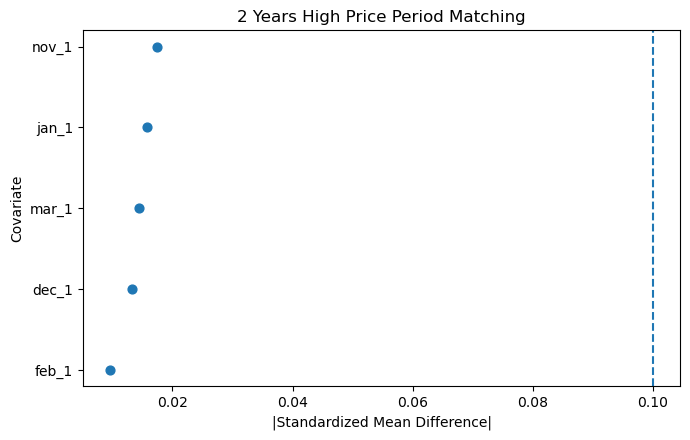

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 117050
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 117758
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [12, 0) ===

--- OVERALL ---
+--------------------+-------------------+-------------------+---------------------+
|covariate           |treated_mean       |control_mean       |SMD                  |
+--------------------+-------------------+-------------------+---------------------+
|peak_mean           |6.309347936739569  |6.111496854761805  |0.0627035810117158   |
|peak_sd             |1.4083722940481795 |1.3663648332710467 |0.0441386214421363   |
|peak_volatility     |0.9089504211513728 |0.8400282334990002 |0.12435735601185517  |
|mean_consumption    |1.3376275475592818 |1.49

In [22]:
# 1 year
# ============================================================
# Step 1: build FULL risk set（🔥不要限制月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,          
    match_months=None,           
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: calendar matching
# ============================================================

print("Running calendar matching...")

res_calendar = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,    # ✅ 改這裡（不能用 sdf）
    output_folder="Files/output/matching/calendar_1year",
    lookback_years=1,
    match_months=[1,2,3,11,12],  # ✅ 在這裡才有用
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar,
    folder="Files/output/matching/calendar_1year",
    config={
        "type": "calendar",
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching"
)


# ============================================================
# Step 5: validation（🔥要傳 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, 31167748-8938-49e1-85de-8269e235d05f, 31, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 11355189
Running calendar matching (k=3)...
Running calendar-aligned matching...
risk_rows count = 11355189
+----------+-------+-------+
|Ti        |group  |count  |
+----------+-------+-------+
|2025-03-01|control|1129558|
|2025-03-01|treated|14952  |
|2025-04-01|control|1130134|
|2025-04-01|treated|8010   |
|2025-05-01|control|1130709|
|2025-05-01|treated|3358   |
|2025-06-01|control|1131266|
|2025-06-01|treated|3000   |
|2025-07-01|control|1131805|
|2025-07-01|treated|1536   |
|2025-08-01|control|1131962|
|2025-08-01|treated|960    |
|2025-09-01|control|1132102|
|2025-09-01|treated|1176   |
|2025-10-01|control|1132228|
|2025-10-01|treated|1200   |
|2025-11-01|control|1132347|
|2025-11-01|treated|3529   |
|2025-12-01|control|1132453|
|2025-12-01|treated|2904   |
+----------+-------+-------+

Building calendar-aligned profiles ...
profiles count = 473892
Standardizing by co

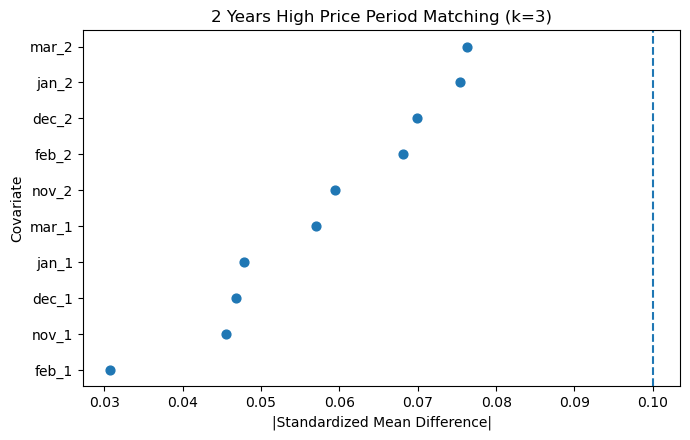

Rebuilding validation data...
  Matching vars window:     [t-24, t-0)
  Non-matching vars window: [t-24, t-0)
Validation rows (matching vars) count = 143420
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 143420
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [24, 0) ===

--- OVERALL ---
+--------------------+-------------------+--------------------+--------------------+
|covariate           |treated_mean       |control_mean        |SMD                 |
+--------------------+-------------------+--------------------+--------------------+
|peak_mean           |6.135699694559981  |5.822549997467205   |0.10345056602552595 |
|peak_sd             |1.6380287405416096 |1.4945387607968517  |0.14864070373689    |
|peak_volatility     |0.9222062290999252 |0.7945828619215051  |0.27717955605252614 |
|mean_consumption    |1.370817787711199  |1.487

In [23]:
# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: calendar matching (k = 3)
# ============================================================

print("Running calendar matching (k=3)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching/calendar2",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    k_neighbors=3,              # ✅ 這個你加得很好
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching/calendar2",
    config={
        "type": "calendar",
        "k_neighbors": 3,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching (k=3)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, e406ffbd-ae73-4018-be38-b55f99de611c, 17, Submitted, Running, Running, True)

Running summary matching 4...
Preparing base data...
Building risk set...
risk_rows count = 5684081
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles coun

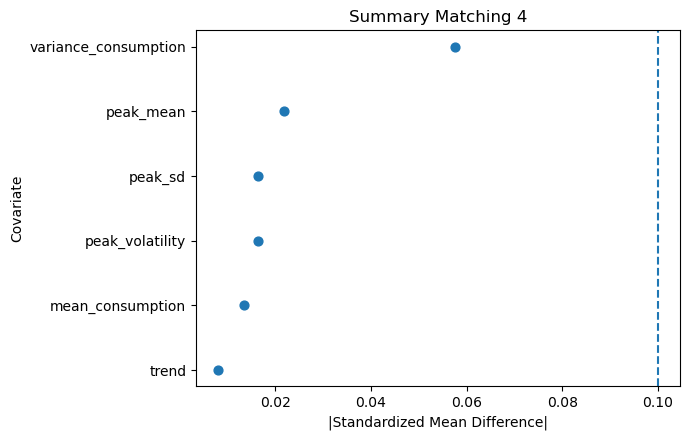

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 116263
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 116602
Profiles rebuilt for non-matching vars

=== MATCHING VARIABLES CHECK [24, 12) ===

--- OVERALL ---
+--------------------+-------------------+-------------------+--------------------+
|covariate           |treated_mean       |control_mean       |SMD                 |
+--------------------+-------------------+-------------------+--------------------+
|peak_mean           |5.956767761022118  |5.882949024345015  |0.023780154370852433|
|peak_sd             |1.4697394903170058 |1.4578843708897675 |0.012325011497039974|
|peak_volatility     |0.9390457522786693 |0.9163131859297008 |0.03987369255709329 |
|mean_consumption    |1.403942311628704  |1.403511612603006  |5.994806207294281E-4|
|variance_consumption|1.4817834425584833 |1.3933344044952283 |0.05657

In [12]:
print("Running summary matching 4...")

# ============================================================
# STEP 0: build risk_rows（🔥必要）
# ============================================================
risk_rows = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,
    control_type="never_treated",
    verbose=True
)

# ============================================================
# STEP 1: matching（🔥改成用 risk_rows）
# ============================================================
res_summary_4 = run_summary_matching_pipeline(
    output_folder="Files/output/matching/summary_4",
    risk_rows=risk_rows,   # 🔥關鍵修正
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# ============================================================
# STEP 2: save（OK）
# ============================================================
save_matching_results_fabric(
    res=res_summary_4,
    folder="Files/output/matching/summary_4",
    config={
        "type": "summary",
        "vars": [
            "peak_mean",
            "peak_sd",
            "peak_volatility",
            "mean_consumption",
            "variance_consumption",
            "trend"
        ]
    },
)

# ============================================================
# STEP 3: love plot（OK）
# ============================================================
love_plot_from_spark(
    res_summary_4["balance"],
    output_path=None,
    title="Summary Matching 4"
)

# ============================================================
# STEP 4: validation（🔥一定要加 sdf）
# ============================================================
check_balance_full_safe(
    res=res_summary_4,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)

StatementMeta(, e406ffbd-ae73-4018-be38-b55f99de611c, 16, Finished, Available, Finished, False)

Preparing seasonal risk set...
Preparing base data...
Building risk set...
risk_rows count = 4732751
Running seasonal summary matching...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473798
Standardizing by controls ...
profiles_z count = 473798
Matching top-k ...
matches count = 8480
Building matc

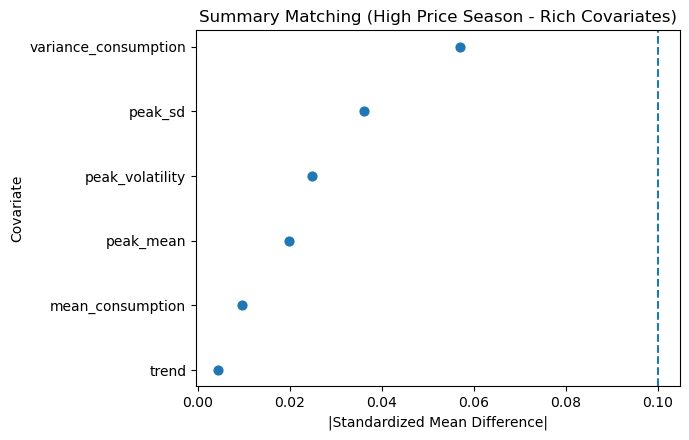

Rebuilding validation data...
  Matching vars window:     [t-24, t-0)
  Non-matching vars window: [t-24, t-0)
Validation rows (matching vars) count = 234159
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 234159
Profiles rebuilt for non-matching vars

=== MATCHING VARIABLES CHECK [24, 0) ===

--- OVERALL ---
+--------------------+-------------------+-------------------+--------------------+
|covariate           |treated_mean       |control_mean       |SMD                 |
+--------------------+-------------------+-------------------+--------------------+
|peak_mean           |6.1349875637783375 |5.9670476744369365 |0.05551391677246704 |
|peak_sd             |1.637975641989158  |1.6144407684992905 |0.02402312329839282 |
|peak_volatility     |0.9224403843304089 |0.8955682747281666 |0.05482025099557596 |
|mean_consumption    |1.3707491818772137 |1.384231768552558  |-0.01966097898178903|
|variance_consumption|1.5756696895209454 |1.460639118482598  |0.0750717

In [11]:
# ============================================================
# Step 1: seasonal risk set（🔥關鍵）
# ============================================================

print("Preparing seasonal risk set...")

risk_rows_season2 = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,
    match_months=[1,2,3,11,12],   # ✅ 季節性在這裡
    control_type="never_treated",
    verbose=True
)


# ============================================================
# Step 2: seasonal summary matching (rich covariates)
# ============================================================

print("Running seasonal summary matching...")

res_summary_season2 = run_summary_matching_pipeline(
    risk_rows=risk_rows_season2,   # ✅ 改這裡
    output_folder="Files/output/matching/summary_season_2",
    lookback_months=24,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_summary_season2,
    folder="Files/output/matching/summary_season2",
    config={
        "type": "summary_season",
        "match_months": [1,2,3,11,12],
        "vars": [
            "peak_mean","peak_sd","peak_volatility",
            "mean_consumption","variance_consumption","trend"
        ]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_summary_season2["balance"],
    output_path=None, 
    title="Summary Matching (High Price Season - Rich Covariates)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================
check_balance_full_safe(
    res=res_summary_season2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0
)